# Coarse-Graining Methods and Selection

We lump 50 demes of a SARS-CoV-2 transmission network into a handful of
"super-demes" three different ways (GPCCA, escape-hitting, MFPT), then check
how much each lumping distorts selection.

## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, SpectralClustering
from scipy.linalg import inv

from pygpcca import GPCCA

import warnings
warnings.filterwarnings("ignore")

# How many super-demes to lump the 50 demes into.
N_CLUSTERS = 4

# Posterior samples of the migration matrix A and effective sizes Ne.
A_samples  = np.load("data/England_Delta_50_EM/output/A_England_Delta.npy")   # (100, 50, 50)
Ne_samples = np.load("data/England_Delta_50_EM/output/Ne_England_Delta.npy")  # (100, 50)

n_samples, n_demes, _ = A_samples.shape

# Use the posterior mean as our point estimate. Rows of A must sum to 1.
A = A_samples.mean(axis=0)
A = A / A.sum(axis=1, keepdims=True)
Ne = Ne_samples.mean(axis=0)

# Shrinking Ne speeds up the Wright-Fisher simulations without changing the
# qualitative behaviour. Used wherever we simulate drift (escape + selection).
NE_SCALE = Ne.mean() / 5.0

print(f"n_demes = {n_demes}, N_CLUSTERS = {N_CLUSTERS}")
print(f"Ne mean = {Ne.mean():.0f}, mean self-migration = {np.diag(A).mean():.3f}")

n_demes = 50, N_CLUSTERS = 4
Ne mean = 1481, mean self-migration = 0.806


### Shared helpers

Small building blocks used by every method below: the stationary distribution,
relaxation timescales, the coarse-grained transition matrix, a Wright-Fisher
step, and two ways to project a fine trajectory onto super-demes.

In [2]:
def stationary(A):
    """Stationary distribution pi of a row-stochastic matrix A (pi @ A = pi)."""
    n = A.shape[0]
    M = A.T - np.eye(n)
    M[-1] = 1.0                      # replace last equation with sum(pi) = 1
    b = np.zeros(n)
    b[-1] = 1.0
    return np.linalg.solve(M, b)


def timescales(A):
    """Relaxation timescales from the sub-dominant eigenvalues of A."""
    eigs = np.sort(np.abs(np.linalg.eigvals(A)))[::-1]
    eigs = np.clip(eigs[1:], 1e-12, 1 - 1e-12)   # drop the leading eigenvalue (= 1)
    return -1.0 / np.log(eigs)


def make_R(labels, m):
    """Lift matrix R (n x m): copies a cluster value down to every deme in it."""
    n = len(labels)
    R = np.zeros((n, m))
    for k in range(m):
        R[labels == k, k] = 1.0
    return R


def make_S(labels, Ne, m):
    """Restriction matrix S (m x n): Ne-weighted average within each cluster."""
    n = len(labels)
    S = np.zeros((m, n))
    for k in range(m):
        inside = labels == k
        if inside.sum() > 0:
            S[k, inside] = Ne[inside] / Ne[inside].sum()
    return S


def coarse_A(labels, A, Ne, m):
    """Coarse-grained transition matrix A' = S A R.

    One coarse step = lift coarse state to fine (R), apply real migration (A),
    compress back to coarse (S).  This is consistent with f' = S f.
    """
    S = make_S(labels, Ne, m)
    R = make_R(labels, m)
    P = S @ A @ R
    P = np.clip(P, 0, None)
    return P / P.sum(axis=1, keepdims=True)


def internal_flow(labels, A, m):
    """Average one-step probability of staying inside each super-deme."""
    out = []
    for k in range(m):
        demes = np.where(labels == k)[0]
        if len(demes) > 1:
            out.append(float(A[np.ix_(demes, demes)].sum(axis=1).mean()))
        else:
            out.append(0.0)
    return out


def wf_step(p, A, Ne):
    """One Wright-Fisher generation: migrate, then binomial-sampling drift."""
    p_mig = A @ p
    p_new = np.zeros_like(p)
    for i in range(len(p)):
        n = max(int(round(Ne[i])), 1)
        p_new[i] = np.random.binomial(n, np.clip(p_mig[i], 0, 1)) / n
    return p_new


def wf_traj(p0, A, Ne, n_steps):
    """Run wf_step for n_steps and return the full trajectory."""
    p = p0.copy()
    traj = [p.copy()]
    for _ in range(n_steps):
        p = wf_step(p, A, Ne)
        traj.append(p.copy())
    return np.array(traj)


def project_fuzzy(traj, chi, Ne, m):
    """Project a fine trajectory onto super-demes using soft memberships chi."""
    out = np.zeros((len(traj), m))
    for k in range(m):
        w = chi[:, k] * Ne
        if w.sum() > 0:
            out[:, k] = traj @ w / w.sum()
    return out


def project_hard(traj, labels, Ne, m):
    """Project a fine trajectory onto super-demes using hard cluster labels."""
    out = np.zeros((len(traj), m))
    for k in range(m):
        demes = np.where(labels == k)[0]
        if len(demes) == 0:
            continue
        w = Ne[demes] / Ne[demes].sum()
        out[:, k] = traj[:, demes] @ w
    return out

## 1. GPCCA

Spectral coarse-graining: GPCCA finds soft memberships `chi` and a coarse
transition matrix directly from the eigen-structure of A.

In [3]:
gpcca = GPCCA(A)
gpcca.optimize(m=N_CLUSTERS)

chi   = gpcca.memberships                                   # soft memberships (n, m)
P_g   = np.clip(gpcca.coarse_grained_transition_matrix, 0, None)
P_g   = P_g / P_g.sum(axis=1, keepdims=True)
Ne_g  = chi.T @ Ne                                          # super-deme sizes
lbl_g = np.argmax(chi, axis=1)                              # hard labels for plotting

print("Coarse transition matrix (GPCCA):")
print(np.round(P_g, 4))
print("\nCluster sizes:", [(lbl_g == k).sum() for k in range(N_CLUSTERS)])
print("Internal flows:", [round(f, 3) for f in internal_flow(lbl_g, A, N_CLUSTERS)])

ts_full = timescales(A)
ts_g = timescales(P_g)
print("\nTimescales (full vs GPCCA):")
for k in range(min(N_CLUSTERS - 1, 4)):
    print(f"  tau_{k+2}: full = {ts_full[k]:.2f}, GPCCA = {ts_g[k]:.2f}")

Coarse transition matrix (GPCCA):
[[0.9305 0.0047 0.0273 0.0375]
 [0.     0.8796 0.0744 0.0461]
 [0.0433 0.0048 0.9104 0.0416]
 [0.0232 0.0058 0.0202 0.9509]]

Cluster sizes: [np.int64(8), np.int64(0), np.int64(7), np.int64(35)]
Internal flows: [0.915, 0.0, 0.894, 0.951]

Timescales (full vs GPCCA):
  tau_2: full = 11.04, GPCCA = 10.97
  tau_3: full = 8.92, GPCCA = 8.09
  tau_4: full = 8.14, GPCCA = 7.48


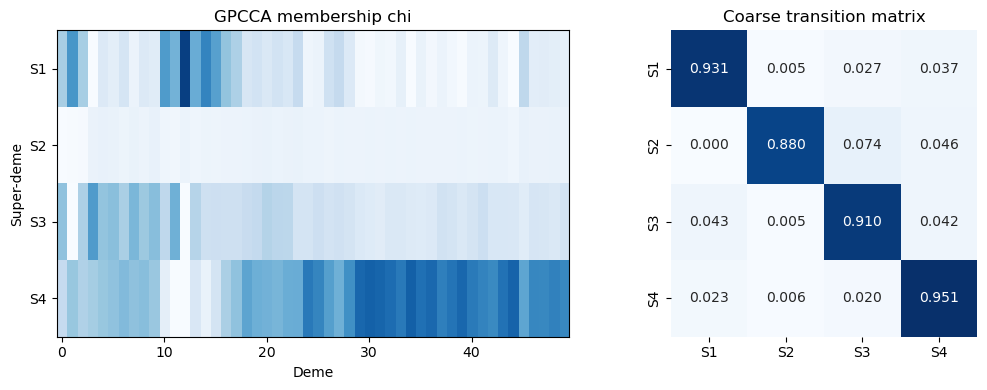

In [4]:
labels = [f"S{k+1}" for k in range(N_CLUSTERS)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(chi.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[0].set_xlabel("Deme")
axes[0].set_ylabel("Super-deme")
axes[0].set_yticks(range(N_CLUSTERS))
axes[0].set_yticklabels(labels)
axes[0].set_title("GPCCA membership chi")

sns.heatmap(P_g, ax=axes[1], annot=True, fmt=".3f", cmap="Blues", square=True,
            cbar=False, xticklabels=labels, yticklabels=labels)
axes[1].set_title("Coarse transition matrix")

plt.tight_layout()
plt.show()

## 2. Escape-Hitting Distribution

Simulate a mutant seeded in each deme and record where it first fixes. Demes
with similar escape destinations get clustered together.

In [5]:
N_TRIALS  = 500
THRESHOLD = 0.5

# Effective sizes scaled down so the simulation runs quickly.
Ne_escape = np.maximum(Ne / NE_SCALE, 1.0)


def first_hit(origin, A, Ne, threshold=0.5, max_gen=2000):
    """Seed one mutant at `origin`; return the deme where it first fixes (-1 if lost)."""
    p = np.zeros(len(Ne))
    p[origin] = 1.0 / max(Ne[origin], 1.0)
    for _ in range(max_gen):
        p = wf_step(p, A, Ne)
        hits = np.where(p > threshold)[0]
        if len(hits):
            return int(hits[np.argmax(p[hits])])
        if p.sum() < 1e-9:        # mutant lost
            return -1
    return -1


# H[i, j] = probability a mutant starting in deme i first fixes in deme j.
H = np.zeros((n_demes, n_demes))
for origin in range(n_demes):
    counts = np.zeros(n_demes)
    lost = 0
    for _ in range(N_TRIALS):
        dest = first_hit(origin, A, Ne_escape, THRESHOLD)
        if dest >= 0:
            counts[dest] += 1
        else:
            lost += 1
    total = counts.sum()
    H[origin] = counts / total if total > 0 else 0.0
    if (origin + 1) % 10 == 0:
        print(f"  deme {origin+1}/{n_demes}, loss = {lost/N_TRIALS:.2f}")
print("done")

  deme 10/50, loss = 0.69
  deme 20/50, loss = 0.88
  deme 30/50, loss = 0.92
  deme 40/50, loss = 0.80
  deme 50/50, loss = 0.70
done


In [6]:
# Cluster demes by their escape distribution (ignore self-fixation).
H_escape = H.copy()
np.fill_diagonal(H_escape, 0.0)
row_sums = H_escape.sum(axis=1, keepdims=True)
row_sums[row_sums < 1e-9] = 1.0
H_escape /= row_sums

km = KMeans(n_clusters=N_CLUSTERS, n_init=50, random_state=42).fit(H_escape)
lbl_e = km.labels_

# Relabel clusters by increasing internal flow so colours are consistent across methods.
order = np.argsort(internal_flow(lbl_e, A, N_CLUSTERS))
relabel = {old: new for new, old in enumerate(order)}
lbl_e = np.array([relabel[l] for l in lbl_e])

P_e  = coarse_A(lbl_e, A, Ne, N_CLUSTERS)
Ne_e = np.array([Ne[lbl_e == k].sum() if (lbl_e == k).sum() > 0 else 1.0
                 for k in range(N_CLUSTERS)])

print("Cluster sizes:", [(lbl_e == k).sum() for k in range(N_CLUSTERS)])
print("Internal flows:", [round(f, 3) for f in internal_flow(lbl_e, A, N_CLUSTERS)])

Cluster sizes: [np.int64(1), np.int64(9), np.int64(20), np.int64(20)]
Internal flows: [0.0, 0.83, 0.897, 0.931]


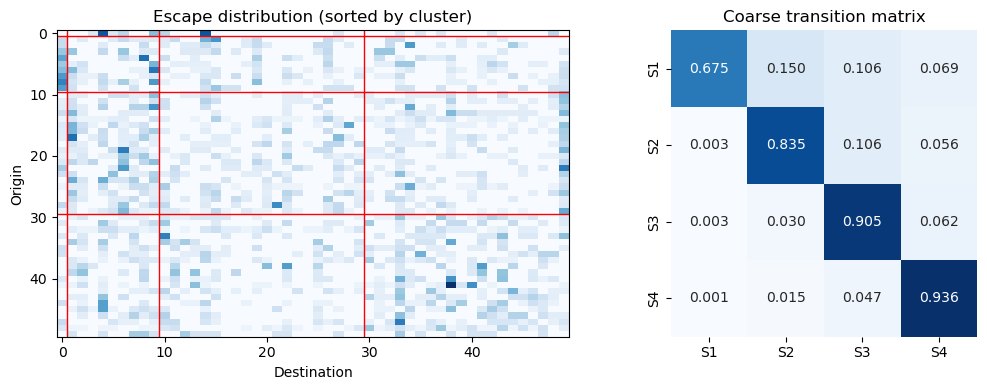

In [7]:
labels = [f"S{k+1}" for k in range(N_CLUSTERS)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order = np.argsort(lbl_e)
axes[0].imshow(H_escape[np.ix_(order, order)], aspect="auto", cmap="Blues")
axes[0].set_title("Escape distribution (sorted by cluster)")
axes[0].set_xlabel("Destination")
axes[0].set_ylabel("Origin")
bounds = np.cumsum([(lbl_e == k).sum() for k in range(N_CLUSTERS)])[:-1]
for b in bounds:
    axes[0].axhline(b - 0.5, color="r", lw=1)
    axes[0].axvline(b - 0.5, color="r", lw=1)

sns.heatmap(P_e, ax=axes[1], annot=True, fmt=".3f", cmap="Blues", square=True,
            cbar=False, xticklabels=labels, yticklabels=labels)
axes[1].set_title("Coarse transition matrix")

plt.tight_layout()
plt.show()

## 3. MFPT

Compute mean first-passage times between demes, turn them into a similarity,
and spectral-cluster. This is the recommended default method.

In [8]:
# Mean first-passage times between demes (fundamental-matrix formula).
pi = stationary(A)
Pi = np.tile(pi, (n_demes, 1))
Z  = inv(np.eye(n_demes) - A + Pi)

T = np.zeros((n_demes, n_demes))
for i in range(n_demes):
    for j in range(n_demes):
        if i != j:
            T[i, j] = (Z[j, j] - Z[i, j]) / pi[j]
T = np.clip(T, 0, np.percentile(T[T > 0], 95))      # cap extreme values

# Turn first-passage times into a similarity and spectral-cluster.
tau = np.median(T[T > 0])
similarity = np.exp(-(T + T.T) / (2 * tau))
np.fill_diagonal(similarity, 0.0)

sc = SpectralClustering(n_clusters=N_CLUSTERS, affinity="precomputed",
                        n_init=50, random_state=42).fit(similarity)
lbl_m = sc.labels_

order = np.argsort(internal_flow(lbl_m, A, N_CLUSTERS))
relabel = {old: new for new, old in enumerate(order)}
lbl_m = np.array([relabel[l] for l in lbl_m])

P_m  = coarse_A(lbl_m, A, Ne, N_CLUSTERS)
Ne_m = np.array([Ne[lbl_m == k].sum() if (lbl_m == k).sum() > 0 else 1.0
                 for k in range(N_CLUSTERS)])

print("Cluster sizes:", [(lbl_m == k).sum() for k in range(N_CLUSTERS)])
print("Internal flows:", [round(f, 3) for f in internal_flow(lbl_m, A, N_CLUSTERS)])

Cluster sizes: [np.int64(11), np.int64(8), np.int64(18), np.int64(13)]
Internal flows: [0.864, 0.883, 0.907, 0.932]


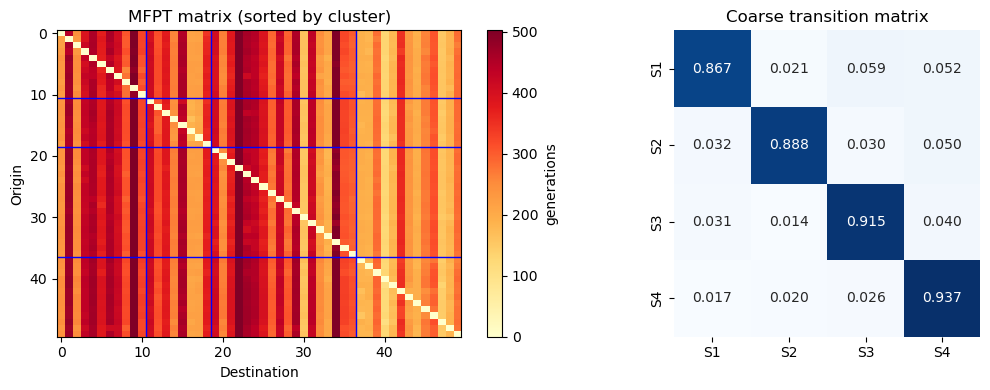

In [9]:
labels = [f"S{k+1}" for k in range(N_CLUSTERS)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

order = np.argsort(lbl_m)
im = axes[0].imshow(T[np.ix_(order, order)], aspect="auto", cmap="YlOrRd")
plt.colorbar(im, ax=axes[0], label="generations")
axes[0].set_title("MFPT matrix (sorted by cluster)")
axes[0].set_xlabel("Destination")
axes[0].set_ylabel("Origin")
bounds = np.cumsum([(lbl_m == k).sum() for k in range(N_CLUSTERS)])[:-1]
for b in bounds:
    axes[0].axhline(b - 0.5, color="b", lw=1)
    axes[0].axvline(b - 0.5, color="b", lw=1)

sns.heatmap(P_m, ax=axes[1], annot=True, fmt=".3f", cmap="Blues", square=True,
            cbar=False, xticklabels=labels, yticklabels=labels)
axes[1].set_title("Coarse transition matrix")

plt.tight_layout()
plt.show()

### Collect the three methods

Put everything in one dict so the validation and selection sections can just
loop over the methods instead of repeating the same config three times.

In [10]:
methods = {
    "GPCCA":  dict(labels=lbl_g, Ne=Ne_g, P=P_g, kind="fuzzy", chi=chi),
    "Escape": dict(labels=lbl_e, Ne=Ne_e, P=P_e, kind="hard",  chi=None),
    "MFPT":   dict(labels=lbl_m, Ne=Ne_m, P=P_m, kind="hard",  chi=None),
}

### Consistency check: does A' = S A R, and does pi' match the projected stationary distribution?


In [11]:
# Consistency check: compare S A R to the old destination-weighted formula.
# These should now be the same since coarse_A was updated to use S A R.
# We also verify that pi' (stationary of A') matches the summed stationary mass.

pi = stationary(A)

for name, method in methods.items():
    if method["kind"] == "fuzzy":
        # for GPCCA use chi-based S and R
        S = make_S(lbl_g, Ne, N_CLUSTERS)
        R = make_R(lbl_g, N_CLUSTERS)
    else:
        S = make_S(method["labels"], Ne, N_CLUSTERS)
        R = make_R(method["labels"], N_CLUSTERS)

    A_SAR = np.clip(S @ A @ R, 0, None)
    A_SAR = A_SAR / A_SAR.sum(axis=1, keepdims=True)

    diff_matrix = np.abs(A_SAR - method["P"]).max()

    pi_coarse = stationary(method["P"])
    mass = R.T @ pi
    diff_pi = np.abs(pi_coarse - mass).max()

    print(f"{name:>10}  {diff_matrix:>16.6f}  {diff_pi:>18.6f}")

print("\nmax|S A R - A\'| should be ~0 since coarse_A now uses S A R.")
print("max|pi\' - R^T pi| will be nonzero unless S uses pi-weights (ours uses Ne-weights).")


     GPCCA               nan            0.076860
    Escape          0.000000            0.069368
      MFPT          0.000000            0.018445

max|S A R - A'| should be ~0 since coarse_A now uses S A R.
max|pi' - R^T pi| will be nonzero unless S uses pi-weights (ours uses Ne-weights).


## 4. Validation

Simulate the full 50-deme model and the coarse model from matched initial
conditions. A good coarse model reproduces the variance of the projected fine
model, so the variance ratio should sit near 1.

In [12]:
N_STEPS = 200
N_SIMS  = 60

initial_conditions = {
    "uniform":   lambda: np.full(n_demes, 0.1),
    "localised": lambda: np.concatenate([[0.5], np.zeros(n_demes - 1)]),
}


def coarse_initial(method, p0):
    """Coarse-grain a fine initial condition into super-deme frequencies."""
    if method["kind"] == "fuzzy":
        chi = method["chi"]
        return np.array([np.dot(chi[:, k] * Ne, p0) / max((chi[:, k] * Ne).sum(), 1e-9)
                         for k in range(N_CLUSTERS)])
    labels = method["labels"]
    out = []
    for k in range(N_CLUSTERS):
        inside = labels == k
        if inside.sum() > 0:
            out.append((Ne[inside] * p0[inside]).sum() / max(Ne[inside].sum(), 1e-9))
        else:
            out.append(0.1)
    return np.array(out)


def project_fine(method, traj):
    """Project a fine trajectory onto super-demes (raw Ne)."""
    if method["kind"] == "fuzzy":
        return project_fuzzy(traj, method["chi"], Ne, N_CLUSTERS)
    return project_hard(traj, method["labels"], Ne, N_CLUSTERS)


results = {}
for ic_name, make_p0 in initial_conditions.items():
    results[ic_name] = {}
    for name, method in methods.items():
        p0_coarse = coarse_initial(method, make_p0())
        proj_runs, coarse_runs = [], []
        for _ in range(N_SIMS):
            fine = wf_traj(make_p0(), A, Ne, N_STEPS)
            proj_runs.append(project_fine(method, fine))
            coarse_runs.append(wf_traj(p0_coarse.copy(), method["P"], method["Ne"], N_STEPS))
        results[ic_name][name] = {"proj": np.array(proj_runs),
                                  "coarse": np.array(coarse_runs)}
    print(f"done: {ic_name}")

done: uniform
done: localised


In [13]:
def variance_ratio(data, t):
    """Mean over super-demes of var(coarse) / var(projected fine) at time t."""
    proj, coarse = data["proj"], data["coarse"]
    ratios = []
    for k in range(N_CLUSTERS):
        v_proj = proj[:, t, k].var()
        if v_proj > 1e-10:
            ratios.append(coarse[:, t, k].var() / v_proj)
    return np.nanmean(ratios) if ratios else np.nan


check_times = [20, 100, N_STEPS]
for ic_name in initial_conditions:
    print(f"\n{ic_name.upper()}")
    print(" " * 10 + "".join(f"  t={t:>4}" for t in check_times))
    for name in methods:
        row = f"{name:>10}"
        for t in check_times:
            row += f"  {variance_ratio(results[ic_name][name], t):>6.3f}"
        print(row)
print("\nideal = 1.0")


UNIFORM
            t=  20  t= 100  t= 200
     GPCCA   1.709   0.653   0.855
    Escape   0.871   0.799   1.006
      MFPT   1.243   0.717   0.723

LOCALISED
            t=  20  t= 100  t= 200
     GPCCA   1.128   0.434   0.340
    Escape   0.777   0.404   0.349
      MFPT   0.622   0.881   0.701

ideal = 1.0


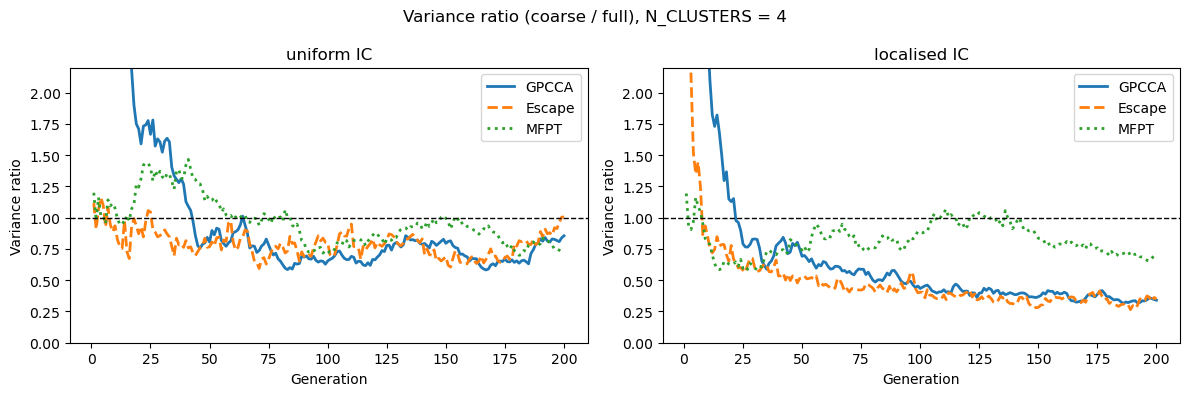

In [14]:
generations = np.arange(N_STEPS + 1)
line_styles = {"GPCCA": "-", "Escape": "--", "MFPT": ":"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, ic_name in zip(axes, initial_conditions):
    for name in methods:
        data = results[ic_name][name]
        vr = [variance_ratio(data, t) for t in generations]
        ax.plot(generations, vr, lw=2, ls=line_styles[name], label=name)
    ax.axhline(1.0, color="k", lw=1, ls="--")
    ax.set_xlabel("Generation")
    ax.set_ylabel("Variance ratio")
    ax.set_title(f"{ic_name} IC")
    ax.set_ylim(0, 2.2)
    ax.legend()

plt.suptitle(f"Variance ratio (coarse / full), N_CLUSTERS = {N_CLUSTERS}")
plt.tight_layout()
plt.show()

## 5. Summary Comparison

Side-by-side timescales, internal flows, and how often the three methods agree
on which super-deme a deme belongs to.

In [15]:
from itertools import permutations


def best_agreement(l1, l2, m):
    """Fraction of demes that agree, maximised over relabelings of l2."""
    return max((l1 == np.array([perm[x] for x in l2])).mean()
               for perm in permutations(range(m)))


# Timescales
print("Timescales:")
print(" " * 8 + f"{'full':>8}" + "".join(f"{n:>10}" for n in methods))
ts_methods = {n: timescales(m["P"]) for n, m in methods.items()}
for k in range(min(N_CLUSTERS - 1, 5)):
    row = f"  tau_{k+2}  {timescales(A)[k]:>7.2f}"
    for n in methods:
        row += f"  {ts_methods[n][k]:>8.2f}"
    print(row)

# Internal flow
print("\nInternal flow:")
for n, m in methods.items():
    flows = internal_flow(m["labels"], A, N_CLUSTERS)
    print(f"  {n:>10}: {[round(x, 3) for x in flows]}  mean = {np.mean(flows):.3f}")

# Cluster agreement
print("\nCluster agreement:")
for a, b in [("GPCCA", "Escape"), ("GPCCA", "MFPT"), ("Escape", "MFPT")]:
    agree = best_agreement(methods[a]["labels"], methods[b]["labels"], N_CLUSTERS)
    print(f"  {a} vs {b}: {agree:.1%}")

Timescales:
            full     GPCCA    Escape      MFPT
  tau_2    11.04     10.97      7.50      9.13
  tau_3     8.92      8.09      4.59      7.32
  tau_4     8.14      7.48      2.51      5.65

Internal flow:
       GPCCA: [0.915, 0.0, 0.894, 0.951]  mean = 0.690
      Escape: [0.0, 0.83, 0.897, 0.931]  mean = 0.665
        MFPT: [0.864, 0.883, 0.907, 0.932]  mean = 0.896

Cluster agreement:
  GPCCA vs Escape: 54.0%
  GPCCA vs MFPT: 62.0%
  Escape vs MFPT: 60.0%


## 6. Selection Robustness

A linear projection `S` commutes with migration but not with the nonlinear
selection term `s f (1 - f)`. These diagnostics measure that mismatch: project
then apply selection vs. apply selection then project.

In [16]:
from scipy.linalg import schur

S_SEL    = 0.05     # selection coefficient to test
N_STEPS  = 200
N_SIMS   = 2000
POST_SUB = 30       # how many posterior samples to average diagnostics over

rng = np.random.default_rng(0)
n_post = A_samples.shape[0]

In [17]:
def wf_step_sel(p, A, Ne, s):
    """Wright-Fisher step with a deterministic selection shift of strength s."""
    p_mig = A @ p
    p_mig = np.clip(p_mig + s * p_mig * (1 - p_mig), 0, 1)
    p_new = np.zeros_like(p)
    for i in range(len(p)):
        n = max(int(round(Ne[i])), 1)
        p_new[i] = np.random.binomial(n, p_mig[i]) / n
    return p_new


def wf_traj_sel(p0, A, Ne, n_steps, s):
    p = p0.copy()
    traj = [p.copy()]
    for _ in range(n_steps):
        p = wf_step_sel(p, A, Ne, s)
        traj.append(p.copy())
    return np.array(traj)


def S_from_labels(labels, Ne, m):
    """Projection matrix S (m x n) from hard labels: Ne-weighted average per cluster."""
    S = np.zeros((m, len(Ne)))
    for k in range(m):
        inside = labels == k
        if inside.sum() > 0:
            S[k, inside] = Ne[inside] / Ne[inside].sum()
    return S


def S_from_chi(chi, Ne, m):
    """Projection matrix S (m x n) from GPCCA soft memberships."""
    S = np.zeros((m, len(Ne)))
    for k in range(m):
        w = chi[:, k] * Ne
        if w.sum() > 0:
            S[k] = w / w.sum()
    return S

In [18]:
def schur_heatmaps(A, m):
    """Show the top m real Schur vectors of A (the GPCCA building blocks)."""
    T, Z = schur(A.T, output="real")
    order = np.argsort(-np.abs(np.diag(T)))
    X = Z[:, order[:m]]
    fig, axes = plt.subplots(1, m, figsize=(2.6 * m, 3.2))
    for k in range(m):
        v = X[:, k]
        scale = np.abs(v).max()
        axes[k].imshow(v.reshape(-1, 1), aspect="auto", cmap="RdBu",
                       vmin=-scale, vmax=scale)
        axes[k].set_title(f"Schur {k}")
        axes[k].set_xticks([])
    plt.tight_layout()
    plt.show()
    return X

In [19]:
def selection_error(S, s, n_post_sub, n_sims=20):
    """
    Distortion that projection S introduces into selection, per posterior sample.
    Compares S applied to the true selection term against selection applied to
    the projected frequencies. Returns one ratio (distortion / signal) per sample.
    """
    ratios = []
    for i in range(n_post_sub):
        Ai = A_samples[i] / A_samples[i].sum(axis=1, keepdims=True)
        Nei = np.maximum(Ne_samples[i] / NE_SCALE, 1.0)
        errors, signal = [], []
        for _ in range(n_sims):
            f0 = rng.uniform(0.2, 0.8, Ai.shape[0])
            traj = wf_traj_sel(f0, Ai, Nei, N_STEPS, s)
            for f in traj[::10]:
                true_term = S @ (s * f * (1 - f))      # project the true selection term
                fp = S @ f
                approx_term = s * fp * (1 - fp)         # selection on projected freq
                errors.append(np.linalg.norm(true_term - approx_term))
                signal.append(np.linalg.norm(true_term))
        ratios.append(np.mean(errors) / (np.mean(signal) + 1e-12))
    return np.array(ratios)

In [20]:
def mismatch(method, s, n_sims=N_SIMS):
    """Final-generation MSE between the projected fine run and the coarse run."""
    Ne_scaled = Ne / NE_SCALE
    Ne_coarse = method["Ne"] / NE_SCALE
    errors = []
    for _ in range(n_sims):
        f0 = rng.uniform(0.2, 0.8, n_demes)
        fine = wf_traj_sel(f0, A, Ne_scaled, N_STEPS, s)
        if method["kind"] == "fuzzy":
            f_true = project_fuzzy(fine, method["chi"], Ne_scaled, N_CLUSTERS)
        else:
            f_true = project_hard(fine, method["labels"], Ne_scaled, N_CLUSTERS)
        f_sim = wf_traj_sel(f_true[0].copy(), method["P"], Ne_coarse, N_STEPS, s)
        errors.append(np.mean((f_true - f_sim) ** 2, axis=1))
    return np.array(errors)

### Learned linear projection

Instead of clustering first, learn the projection `S` directly by gradient
descent on a one-step consistency loss. The anti-collapse penalty keeps all
super-demes populated; columns of the returned `S` sum to 1.

In [21]:
def learn_linear_S(m, s, steps=800, lr=5e-3, batch=12, beta=0.5):
    """Learn a projection S (m x n) by gradient descent on a one-step consistency loss."""
    n = A.shape[0]
    S = rng.normal(0, 0.1, (m, n))

    def column_stochastic(S):
        S = np.abs(S)
        return S / (S.sum(axis=0, keepdims=True) + 1e-12)

    for step in range(steps):
        grad = np.zeros_like(S)
        loss = 0.0
        labels = np.argmax(column_stochastic(S), axis=0)

        for _ in range(batch):
            i = rng.integers(min(POST_SUB, n_post))
            Ai = A_samples[i] / A_samples[i].sum(axis=1, keepdims=True)
            Nei = np.maximum(Ne_samples[i] / NE_SCALE, 1.0)
            f0 = rng.uniform(0.2, 0.8, n)
            fine = wf_traj_sel(f0, Ai, Nei, N_STEPS, s)
            Ac = coarse_A(labels, Ai, Nei, m)
            for t in range(len(fine) - 1):
                z = np.clip(S @ fine[t], 0, 1)
                pred = np.clip(Ac @ z + s * z * (1 - z), 0, 1)
                resid = np.clip(S @ fine[t + 1], 0, 1) - pred
                loss += np.sum(resid ** 2)
                grad += 2 * np.outer(resid, fine[t + 1])

        grad /= batch * N_STEPS
        loss /= batch * N_STEPS

        # Anti-collapse: keep total weight roughly equal across super-demes.
        weight = np.abs(S).sum(axis=1)
        target = weight.sum() / m
        loss += beta * np.sum((weight - target) ** 2) / (target ** 2 + 1e-12)
        grad += beta * 2 * (weight - target)[:, None] * np.sign(S) / (target ** 2 + 1e-12)

        # Gradient clipping for stability.
        norm = np.linalg.norm(grad)
        if norm > 5.0:
            grad *= 5.0 / norm
        S -= lr * grad

        if step % 100 == 0:
            print(f"  [learn S] step {step:4d}  loss {loss:.4e}")

    return column_stochastic(S)

### Run the diagnostics

== Schur vector heatmaps ==


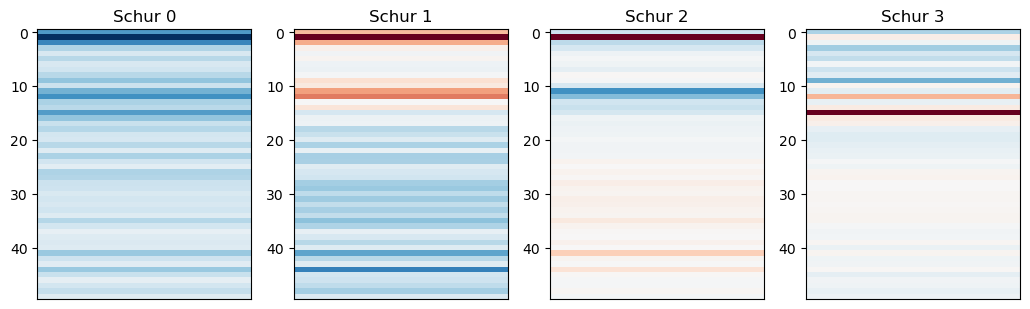


== Selection-error ratio across posterior (lower = more robust) ==
  GPCCA  : 0.636 +/- 0.046
  Escape : 0.512 +/- 0.036
  MFPT   : 0.640 +/- 0.054

== Trajectory mismatch (final-gen MSE) at s=0 and s=S_SEL ==
  GPCCA   s=0.0 : 2.7534e-01
  GPCCA   s=0.05: 9.7558e-04
  Escape  s=0.0 : 3.0378e-01
  Escape  s=0.05: 8.7421e-04
  MFPT    s=0.0 : 3.1099e-01
  MFPT    s=0.05: 4.3617e-04

== Learned linear S ==
  [learn S] step    0  loss 1.8777e-02
  [learn S] step  100  loss 1.2693e-02
  [learn S] step  200  loss 2.2807e-02
  [learn S] step  300  loss 2.5735e-02
  [learn S] step  400  loss 2.1940e-02
  [learn S] step  500  loss 1.8709e-02
  [learn S] step  600  loss 2.3504e-02
  [learn S] step  700  loss 2.5672e-02
  learned s=0.05: 9.0877e-04
  learned cluster sizes: [13, 15, 10, 12]


In [22]:
print("== Schur vector heatmaps ==")
schur_heatmaps(A, N_CLUSTERS)

print("\n== Selection-error ratio across posterior (lower = more robust) ==")
S_matrices = {
    "GPCCA":  S_from_chi(chi, Ne / NE_SCALE, N_CLUSTERS),
    "Escape": S_from_labels(lbl_e, Ne / NE_SCALE, N_CLUSTERS),
    "MFPT":   S_from_labels(lbl_m, Ne / NE_SCALE, N_CLUSTERS),
}
for name, S in S_matrices.items():
    r = selection_error(S, S_SEL, POST_SUB)
    print(f"  {name:7s}: {r.mean():.3f} +/- {r.std():.3f}")

print("\n== Trajectory mismatch (final-gen MSE) at s=0 and s=S_SEL ==")
for name, method in methods.items():
    for s_val in [0.0, S_SEL]:
        e = mismatch(method, s_val)
        print(f"  {name:7s} s={s_val:<4}: {e[:, -1].mean():.4e}")

print("\n== Learned linear S ==")
S_lin = learn_linear_S(N_CLUSTERS, S_SEL)
lbl_lin = np.argmax(S_lin, axis=0)
Ne_lin = np.array([Ne[lbl_lin == k].sum() if (lbl_lin == k).sum() > 0 else 1.0
                   for k in range(N_CLUSTERS)])
P_lin = coarse_A(lbl_lin, A, Ne, N_CLUSTERS)
method_lin = dict(labels=lbl_lin, Ne=Ne_lin, P=P_lin, kind="hard", chi=None)
e = mismatch(method_lin, S_SEL)
print(f"  learned s={S_SEL}: {e[:, -1].mean():.4e}")
print(f"  learned cluster sizes: {[int((lbl_lin == k).sum()) for k in range(N_CLUSTERS)]}")

### Trajectory and selection-error plots

trajectory mismatch at s = S_SEL


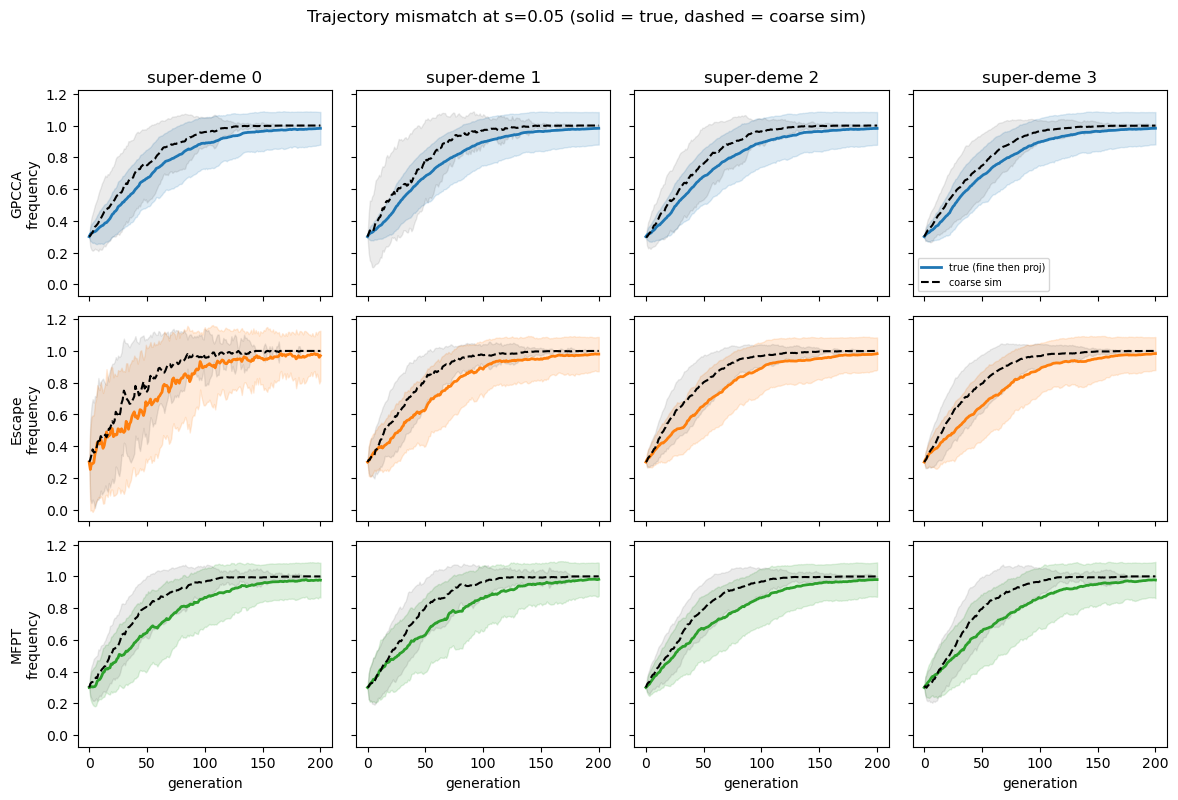

trajectory mismatch at s = 0


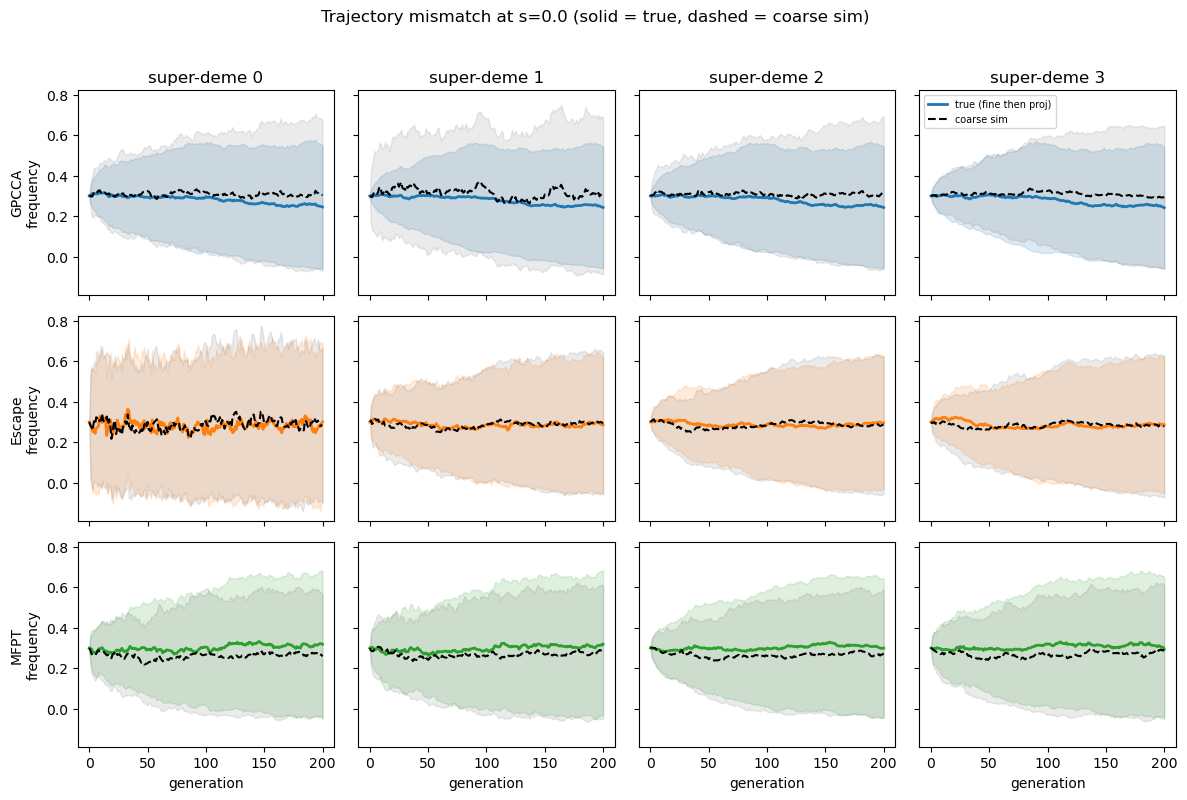

selection-error decomposition


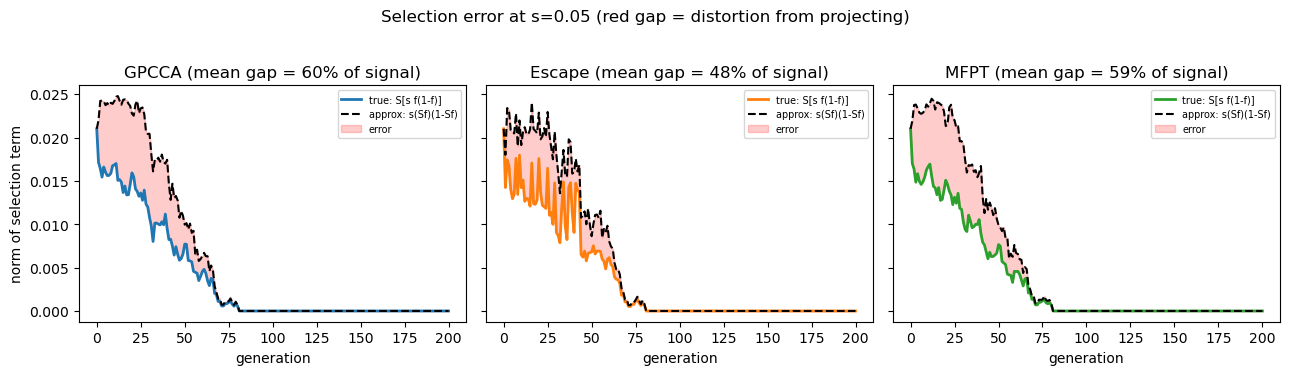

In [23]:
COLORS = {"GPCCA": "#1f77b4", "Escape": "#ff7f0e", "MFPT": "#2ca02c"}
Ne_scaled = Ne / NE_SCALE


def trajectory_plot(s, n_sims=100, T=200):
    """For each method: true (fine then projected) vs coarse-simulated trajectory."""
    fig, axes = plt.subplots(len(methods), N_CLUSTERS,
                             figsize=(3 * N_CLUSTERS, 2.6 * len(methods)),
                             sharex=True, sharey=True)
    f0 = np.full(n_demes, 0.3)
    for row, (name, method) in enumerate(methods.items()):
        Ne_coarse = method["Ne"] / NE_SCALE
        true_runs, sim_runs = [], []
        for _ in range(n_sims):
            fine = wf_traj_sel(f0, A, Ne_scaled, T, s)
            if method["kind"] == "fuzzy":
                f_true = project_fuzzy(fine, method["chi"], Ne_scaled, N_CLUSTERS)
            else:
                f_true = project_hard(fine, method["labels"], Ne_scaled, N_CLUSTERS)
            f_sim = wf_traj_sel(f_true[0].copy(), method["P"], Ne_coarse, T, s)
            true_runs.append(f_true)
            sim_runs.append(f_sim)
        true_runs = np.array(true_runs)
        sim_runs = np.array(sim_runs)
        true_mean, true_sd = true_runs.mean(0), true_runs.std(0)
        sim_mean, sim_sd = sim_runs.mean(0), sim_runs.std(0)
        gen = np.arange(T + 1)
        for k in range(N_CLUSTERS):
            ax = axes[row, k]
            ax.plot(gen, true_mean[:, k], color=COLORS[name], lw=2, label="true (fine then proj)")
            ax.fill_between(gen, true_mean[:, k] - true_sd[:, k], true_mean[:, k] + true_sd[:, k],
                            color=COLORS[name], alpha=0.15)
            ax.plot(gen, sim_mean[:, k], color="k", lw=1.5, ls="--", label="coarse sim")
            ax.fill_between(gen, sim_mean[:, k] - sim_sd[:, k], sim_mean[:, k] + sim_sd[:, k],
                            color="k", alpha=0.08)
            if row == 0:
                ax.set_title(f"super-deme {k}")
            if k == 0:
                ax.set_ylabel(f"{name}\nfrequency")
            if row == len(methods) - 1:
                ax.set_xlabel("generation")
            if row == 0 and k == N_CLUSTERS - 1:
                ax.legend(fontsize=7)
    fig.suptitle(f"Trajectory mismatch at s={s} (solid = true, dashed = coarse sim)", y=1.02)
    plt.tight_layout()
    plt.show()


def selection_error_plot(s, T=200):
    """Show the gap between projecting selection and selecting on projections."""
    S_matrices = {
        "GPCCA":  S_from_chi(chi, Ne_scaled, N_CLUSTERS),
        "Escape": S_from_labels(lbl_e, Ne_scaled, N_CLUSTERS),
        "MFPT":   S_from_labels(lbl_m, Ne_scaled, N_CLUSTERS),
    }
    f0 = np.full(n_demes, 0.3)
    fine = wf_traj_sel(f0, A, Ne_scaled, T, s)
    gen = np.arange(T + 1)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
    for ax, (name, S) in zip(axes, S_matrices.items()):
        true_term = np.array([np.linalg.norm(S @ (s * f * (1 - f))) for f in fine])
        fp = (S @ fine.T).T
        approx_term = np.array([np.linalg.norm(s * z * (1 - z)) for z in fp])
        ax.plot(gen, true_term, color=COLORS[name], lw=2, label="true: S[s f(1-f)]")
        ax.plot(gen, approx_term, color="k", lw=1.5, ls="--", label="approx: s(Sf)(1-Sf)")
        ax.fill_between(gen, np.minimum(true_term, approx_term),
                        np.maximum(true_term, approx_term), color="red", alpha=0.2, label="error")
        ratio = np.abs(true_term - approx_term).mean() / (true_term.mean() + 1e-12)
        ax.set_title(f"{name} (mean gap = {ratio:.0%} of signal)")
        ax.set_xlabel("generation")
        ax.legend(fontsize=7)
    axes[0].set_ylabel("norm of selection term")
    fig.suptitle(f"Selection error at s={s} (red gap = distortion from projecting)", y=1.03)
    plt.tight_layout()
    plt.show()


print("trajectory mismatch at s = S_SEL")
trajectory_plot(S_SEL)
print("trajectory mismatch at s = 0")
trajectory_plot(0.0)
print("selection-error decomposition")
selection_error_plot(S_SEL)

### Side-by-side assignments

GPCCA    agreement vs GPCCA: 100%  sizes = [8, 0, 7, 35]
Escape   agreement vs GPCCA: 54%  sizes = [20, 1, 9, 20]
MFPT     agreement vs GPCCA: 62%  sizes = [13, 11, 8, 18]
Learned  agreement vs GPCCA: 36%  sizes = [13, 10, 12, 15]


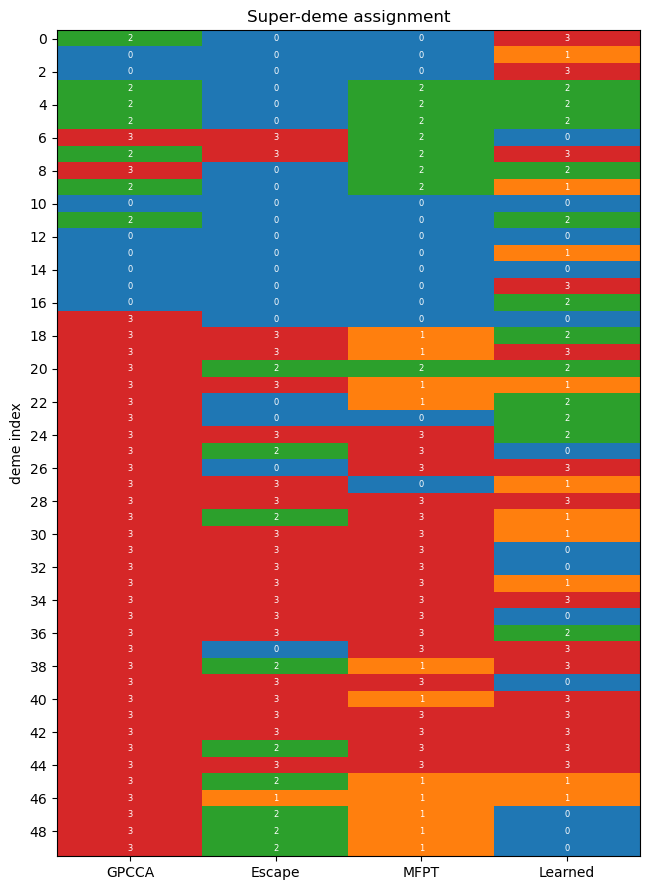

In [24]:
def align(reference, labels, m):
    """Relabel `labels` to best match `reference`; return aligned labels and score."""
    best_score, best_perm = -1, tuple(range(m))
    for perm in permutations(range(m)):
        score = (np.array([perm[l] for l in labels]) == reference).mean()
        if score > best_score:
            best_score, best_perm = score, perm
    return np.array([best_perm[l] for l in labels]), best_score


all_labels = {name: m["labels"] for name, m in methods.items()}
all_coarse = {name: m["P"] for name, m in methods.items()}
if "lbl_lin" in dir():
    all_labels["Learned"] = lbl_lin
    all_coarse["Learned"] = P_lin

reference = lbl_g
aligned = {}
for name, labels in all_labels.items():
    a, score = align(reference, labels, N_CLUSTERS)
    aligned[name] = a
    print(f"{name:8s} agreement vs GPCCA: {score:.0%}  "
          f"sizes = {[int((a == k).sum()) for k in range(N_CLUSTERS)]}")

names = list(all_labels.keys())
assignment = np.array([aligned[n] for n in names]).T      # (n_demes, n_methods)

fig, ax = plt.subplots(figsize=(1.4 * len(names) + 1, 9))
ax.imshow(assignment, aspect="auto", cmap="tab10", vmin=0, vmax=9, interpolation="nearest")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_yticks(range(0, n_demes, 2))
ax.set_ylabel("deme index")
ax.set_title("Super-deme assignment")
for i in range(n_demes):
    for j in range(len(names)):
        ax.text(j, i, str(assignment[i, j]), ha="center", va="center", fontsize=6, color="white")
plt.tight_layout()
plt.show()

  step    0  loss 2.0324e-02  cluster sizes [np.int64(15), np.int64(14), np.int64(12), np.int64(9)]
  step  100  loss 2.1377e-02  cluster sizes [np.int64(15), np.int64(15), np.int64(10), np.int64(10)]
  step  200  loss 1.8867e-02  cluster sizes [np.int64(15), np.int64(14), np.int64(11), np.int64(10)]
  step  300  loss 1.5663e-02  cluster sizes [np.int64(15), np.int64(14), np.int64(11), np.int64(10)]
  step  400  loss 1.9622e-02  cluster sizes [np.int64(15), np.int64(13), np.int64(11), np.int64(11)]
  step  500  loss 2.0412e-02  cluster sizes [np.int64(16), np.int64(14), np.int64(11), np.int64(9)]
  step  600  loss 2.5022e-02  cluster sizes [np.int64(16), np.int64(14), np.int64(11), np.int64(9)]
  step  700  loss 2.6592e-02  cluster sizes [np.int64(16), np.int64(14), np.int64(11), np.int64(9)]
  step  800  loss 2.4321e-02  cluster sizes [np.int64(15), np.int64(13), np.int64(11), np.int64(11)]
  step  900  loss 2.9306e-02  cluster sizes [np.int64(15), np.int64(12), np.int64(12), np.int64

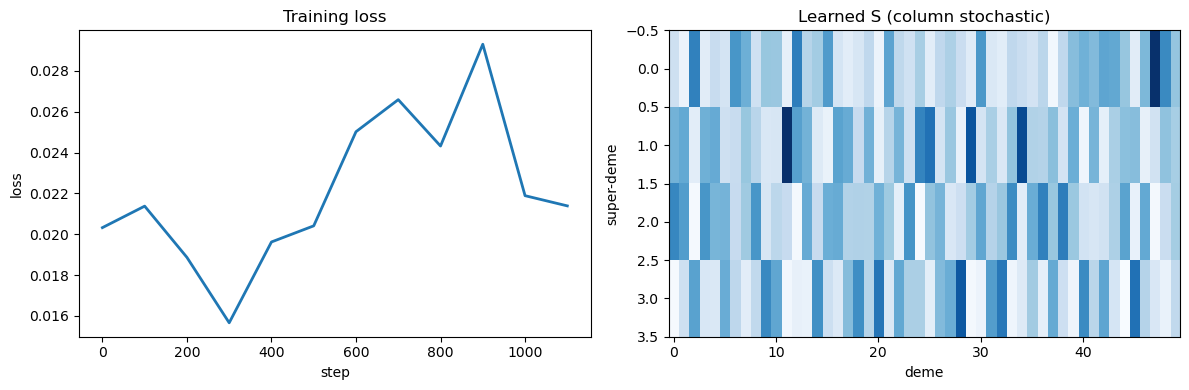

cluster sizes: [np.int64(11), np.int64(11), np.int64(13), np.int64(15)]

Var_within comparison (lower = better for selection):


NameError: name 'within_cluster_var' is not defined

In [32]:
def learn_linear_S(m, s, steps=800, lr=5e-3, batch=12, beta=0.5, seed=0):
    rng_l = np.random.default_rng(seed)
    n = A.shape[0]
    S = rng_l.normal(0, 0.1, (m, n))

    def column_stochastic(S):
        S = np.abs(S)
        return S / (S.sum(axis=0, keepdims=True) + 1e-12)

    losses = []
    for step in range(steps):
        grad = np.zeros_like(S)
        loss = 0.0
        labels = np.argmax(column_stochastic(S), axis=0)

        for _ in range(batch):
            i = rng_l.integers(min(POST_SUB, n_post))
            Ai = A_samples[i] / A_samples[i].sum(axis=1, keepdims=True)
            Nei = np.maximum(Ne_samples[i] / NE_SCALE, 1.0)
            f0_l = rng_l.uniform(0.2, 0.8, n)
            fine = wf_traj_sel(f0_l, Ai, Nei, N_STEPS, s)
            Ac = coarse_A(labels, Ai, Nei, m)
            for t in range(len(fine) - 1):
                z = np.clip(S @ fine[t], 0, 1)
                pred = np.clip(Ac @ z + s * z * (1 - z), 0, 1)
                resid = np.clip(S @ fine[t + 1], 0, 1) - pred
                loss += np.sum(resid ** 2)
                grad += 2 * np.outer(resid, fine[t + 1])

        grad /= batch * N_STEPS
        loss /= batch * N_STEPS

        # anti-collapse penalty
        weight = np.abs(S).sum(axis=1)
        target = weight.sum() / m
        loss += beta * np.sum((weight - target) ** 2) / (target ** 2 + 1e-12)
        grad += beta * 2 * (weight - target)[:, None] * np.sign(S) / (target ** 2 + 1e-12)

        # gradient clipping
        norm = np.linalg.norm(grad)
        if norm > 5.0:
            grad *= 5.0 / norm
        S -= lr * grad

        if step % 100 == 0:
            losses.append(loss)
            print(f"  step {step:4d}  loss {loss:.4e}  "
                  f"cluster sizes {sorted([(labels==k).sum() for k in range(m)], reverse=True)}")

    S_final = column_stochastic(S)
    lbl_final = np.argmax(S_final, axis=0)

    # plot loss curve
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.arange(len(losses)) * 100, losses, lw=2)
    axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")
    axes[0].set_title("Training loss")

    # plot S matrix
    axes[1].imshow(S_final, aspect="auto", cmap="Blues", vmin=0, vmax=S_final.max())
    axes[1].set_xlabel("deme"); axes[1].set_ylabel("super-deme")
    axes[1].set_title("Learned S (column stochastic)")
    plt.tight_layout(); plt.show()

    return S_final, lbl_final

# run it
S_lin, lbl_lin = learn_linear_S(N_CLUSTERS, S_SEL, steps=1200, lr=1e-3, beta=0.1)
print(f"cluster sizes: {[(lbl_lin==k).sum() for k in range(N_CLUSTERS)]}")

# compare Var_within to other methods
print("\nVar_within comparison (lower = better for selection):")
f_test = np.random.default_rng(0).uniform(0.1, 0.9, n_demes)
for name, method in methods.items():
    S_m = (S_from_chi(method["chi"], Ne, N_CLUSTERS) if method["kind"] == "fuzzy"
           else S_from_labels(method["labels"], Ne, N_CLUSTERS))
    var = within_cluster_var(method, f_test)
    print(f"  {name:>10}: mean Var_within = {var.mean():.5f}")

S_learned_ne = S_from_labels(lbl_lin, Ne, N_CLUSTERS)
var_learned = np.array([
    (lambda ins, w: (w * f_test[ins]**2).sum() - (w * f_test[ins]).sum()**2)(
        lbl_lin == k,
        Ne[lbl_lin == k] / Ne[lbl_lin == k].sum()
    ) for k in range(N_CLUSTERS)
])
print(f"  {'Learned':>10}: mean Var_within = {var_learned.mean():.5f}")

warm-start from MFPT:
  step    0  loss 4.2049e-03
  step  100  loss 4.4817e-03
  step  200  loss 4.3150e-03
  step  300  loss 4.8706e-03
  step  400  loss 4.6805e-03
  step  500  loss 3.5695e-03
  step  600  loss 4.1938e-03
  step  700  loss 4.7048e-03

warm-start from Escape:
  step    0  loss 1.6970e-02
  step  100  loss 2.6027e-02
  step  200  loss 2.2369e-02
  step  300  loss 1.7549e-02
  step  400  loss 2.1296e-02
  step  500  loss 2.0865e-02
  step  600  loss 1.8339e-02
  step  700  loss 1.5732e-02


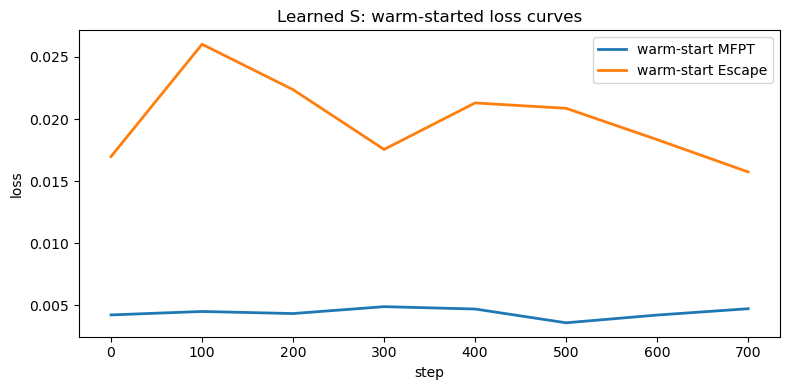

In [33]:
def learn_linear_S_warmstart(m, s, init_labels, steps=800, lr=1e-3, beta=0.05, seed=0):
    """Learn S with fixed cluster structure initialized from another method."""
    rng_l = np.random.default_rng(seed)
    n = A.shape[0]

    # initialize S from the provided labels
    S = np.zeros((m, n))
    for k in range(m):
        ins = init_labels == k
        if ins.sum() > 0:
            S[k, ins] = Ne[ins] / Ne[ins].sum()
    S += rng_l.normal(0, 0.01, S.shape)   # small perturbation

    def row_stochastic(S):
        S = np.abs(S)
        return S / (S.sum(axis=1, keepdims=True) + 1e-12)

    # fix Ac from initial labels -- don't update it during optimization
    Ac = coarse_A(init_labels, A, Ne, m)

    losses = []
    for step in range(steps):
        grad = np.zeros_like(S)
        loss = 0.0
        S_rs = row_stochastic(S)

        for _ in range(batch):
            i = rng_l.integers(min(POST_SUB, n_post))
            Ai = A_samples[i] / A_samples[i].sum(axis=1, keepdims=True)
            Nei = np.maximum(Ne_samples[i] / NE_SCALE, 1.0)
            f0_l = rng_l.uniform(0.05, 0.3, n)   # small f -> linear regime
            fine = wf_traj_sel(f0_l, Ai, Nei, N_STEPS, s)

            for t in range(len(fine) - 1):
                z = np.clip(S_rs @ fine[t], 0, 1)
                pred = np.clip(Ac @ z + s * z * (1 - z), 0, 1)
                resid = np.clip(S_rs @ fine[t + 1], 0, 1) - pred
                loss += np.sum(resid ** 2)
                grad += 2 * np.outer(resid, fine[t + 1])

        grad /= batch * N_STEPS
        loss /= batch * N_STEPS

        # small anti-collapse penalty
        weight = S_rs.sum(axis=1)
        target = 1.0
        loss += beta * np.sum((weight - target) ** 2)
        grad += beta * 2 * (weight - target)[:, None] * np.sign(S)

        norm = np.linalg.norm(grad)
        if norm > 1.0:
            grad *= 1.0 / norm
        S -= lr * grad

        if step % 100 == 0:
            losses.append(loss)
            print(f"  step {step:4d}  loss {loss:.4e}")

    return row_stochastic(S), losses

batch = 12

# try warm-starting from MFPT (best trajectory mismatch)
print("warm-start from MFPT:")
S_mfpt_learned, losses_mfpt = learn_linear_S_warmstart(
    N_CLUSTERS, S_SEL, lbl_m, steps=800, lr=1e-3, beta=0.05)

print("\nwarm-start from Escape:")
S_esc_learned, losses_esc = learn_linear_S_warmstart(
    N_CLUSTERS, S_SEL, lbl_e, steps=800, lr=1e-3, beta=0.05)

# plot loss curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(len(losses_mfpt))*100, losses_mfpt, lw=2, label="warm-start MFPT")
ax.plot(np.arange(len(losses_esc))*100, losses_esc, lw=2, label="warm-start Escape")
ax.set_xlabel("step"); ax.set_ylabel("loss")
ax.set_title("Learned S: warm-started loss curves")
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
print("warm-start from MFPT:")
S_mfpt_learned, losses_mfpt = learn_linear_S_warmstart(
    N_CLUSTERS, S_SEL, lbl_m, steps=1000, lr=2e-4, beta=0.05)

print("\nwarm-start from Escape:")
S_esc_learned, losses_esc = learn_linear_S_warmstart(
    N_CLUSTERS, S_SEL, lbl_e, steps=1000, lr=2e-4, beta=0.05)

warm-start from MFPT:
  step    0  loss 3.4425e-03
  step  100  loss 4.0159e-03


KeyboardInterrupt: 

In [ ]:
def learn_linear_S_deterministic(m, s, init_labels, steps=2000, lr=1e-3, beta=0.05, seed=0):
    """Learn S using deterministic trajectories (no WF noise) warm-started from init_labels."""
    rng_l = np.random.default_rng(seed)
    n = A.shape[0]

    # initialize S from provided labels (Ne-weighted rows)
    S = np.zeros((m, n))
    for k in range(m):
        ins = init_labels == k
        if ins.sum() > 0:
            S[k, ins] = Ne[ins] / Ne[ins].sum()
    S += rng_l.normal(0, 0.005, S.shape)   # tiny perturbation

    def row_stochastic(S):
        S = np.abs(S)
        return S / (S.sum(axis=1, keepdims=True) + 1e-12)

    # fix Ac from initial labels
    Ac = coarse_A(init_labels, A, Ne, m)

    losses = []
    for step in range(steps):
        grad = np.zeros_like(S)
        loss = 0.0
        S_rs = row_stochastic(S)

        # use multiple initial conditions to get better gradient estimate
        for _ in range(20):
            # deterministic trajectory -- no WF sampling
            f0_l = rng_l.uniform(0.02, 0.4, n)   # small f, linear regime
            f = f0_l.copy()
            for t in range(N_STEPS):
                f_next = A @ f + s * f * (1 - f)   # deterministic step
                z      = np.clip(S_rs @ f, 0, 1)
                pred   = np.clip(Ac @ z + s * z * (1 - z), 0, 1)
                resid  = np.clip(S_rs @ f_next, 0, 1) - pred
                loss  += np.sum(resid ** 2)
                grad  += 2 * np.outer(resid, f_next)
                f      = f_next

        grad /= 20 * N_STEPS
        loss /= 20 * N_STEPS

        # anti-collapse
        weight = S_rs.sum(axis=1)
        loss += beta * np.sum((weight - 1.0) ** 2)
        grad += beta * 2 * (weight - 1.0)[:, None] * np.sign(S)

        norm = np.linalg.norm(grad)
        if norm > 1.0:
            grad *= 1.0 / norm
        S -= lr * grad

        if step % 100 == 0:
            losses.append(loss)
            lbl_cur = np.argmax(row_stochastic(S), axis=0)
            print(f"  step {step:4d}  loss {loss:.4e}  "
                  f"sizes {sorted([(lbl_cur==k).sum() for k in range(m)], reverse=True)}")

    S_final = row_stochastic(S)
    lbl_final = np.argmax(S_final, axis=0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(np.arange(len(losses)) * 100, losses, lw=2)
    axes[0].set_xlabel("step"); axes[0].set_ylabel("loss")
    axes[0].set_title("Training loss (deterministic)")

    axes[1].imshow(S_final, aspect="auto", cmap="Blues", vmin=0, vmax=S_final.max())
    axes[1].set_xlabel("deme"); axes[1].set_ylabel("super-deme")
    axes[1].set_title("Learned S (row stochastic)")
    for k in range(m):
        for i in range(n):
            axes[1].text(i, k, f"{S_final[k,i]:.2f}", ha="center", va="center",
                        fontsize=4, color="white" if S_final[k,i] > 0.3 else "black")
    plt.tight_layout(); plt.show()

    return S_final, lbl_final


print("Deterministic warm-start from MFPT:")
S_det_mfpt, lbl_det_mfpt = learn_linear_S_deterministic(
    N_CLUSTERS, S_SEL, lbl_m, steps=2000, lr=1e-3, beta=0.05)

print("\nDeterministic warm-start from Escape:")
S_det_esc, lbl_det_esc = learn_linear_S_deterministic(
    N_CLUSTERS, S_SEL, lbl_e, steps=2000, lr=1e-3, beta=0.05)

# compare Var_within across all methods including learned
print("\nVar_within comparison (lower = better for selection):")
f_test = rng.uniform(0.1, 0.9, n_demes)
for name, method in methods.items():
    var = within_cluster_var(method, f_test)
    print(f"  {name:>15}: mean Var_within = {var.mean():.5f}")

for name, lbl in [("Det MFPT", lbl_det_mfpt), ("Det Escape", lbl_det_esc)]:
    var = np.array([
        (Ne[lbl==k] / Ne[lbl==k].sum() * f_test[lbl==k]**2).sum() -
        ((Ne[lbl==k] / Ne[lbl==k].sum()) * f_test[lbl==k]).sum()**2
        if (lbl==k).sum() > 0 else 0.0
        for k in range(N_CLUSTERS)
    ])
    print(f"  {name:>15}: mean Var_within = {var.mean():.5f}")

Deterministic warm-start from MFPT:
  step    0  loss 2.4739e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  100  loss 2.6030e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  200  loss 2.9325e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  300  loss 3.0341e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  400  loss 2.5693e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  500  loss 3.4368e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  600  loss 2.6830e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  700  loss 2.2527e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  800  loss 2.9458e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step  900  loss 2.4284e-07  sizes [np.int64(18), np.int64(13), np.int64(11), np.int64(8)]
  step 1000  loss 3.0271e-07  sizes [np.int6

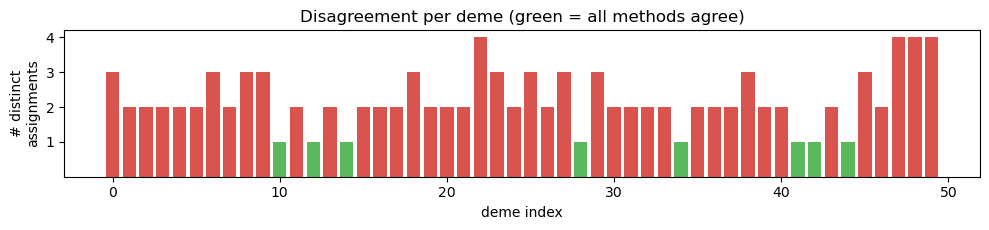

demes where all methods agree: 8/50
demes fully split: 4/50


In [25]:
# How many methods disagree on each deme.
distinct = np.array([len(set(assignment[i])) for i in range(n_demes)])

fig, ax = plt.subplots(figsize=(10, 2.4))
ax.bar(range(n_demes), distinct,
       color=["#d9534f" if d > 1 else "#5cb85c" for d in distinct])
ax.set_xlabel("deme index")
ax.set_ylabel("# distinct\nassignments")
ax.set_title("Disagreement per deme (green = all methods agree)")
ax.set_yticks(range(1, len(names) + 1))
plt.tight_layout()
plt.show()

print(f"demes where all methods agree: {(distinct == 1).sum()}/{n_demes}")
print(f"demes fully split: {(distinct == len(names)).sum()}/{n_demes}")

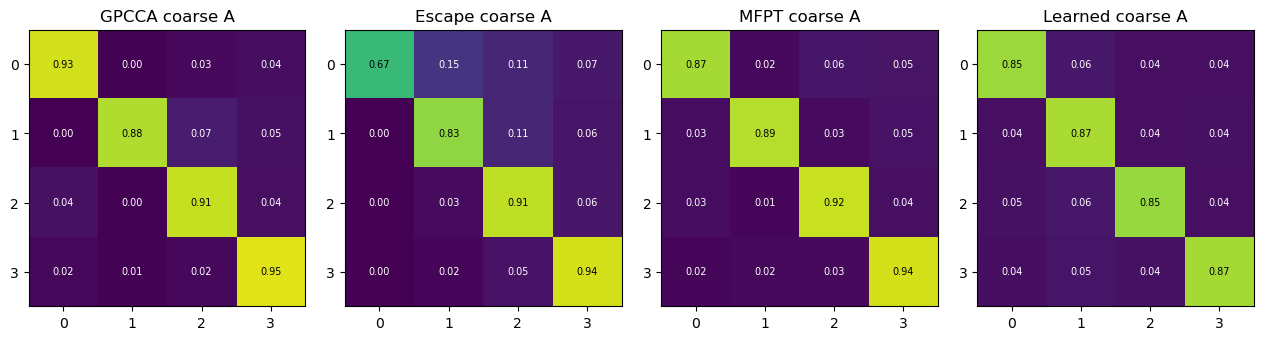

per-cluster self-transition (diagonal of coarse A) - higher = more metastable
  GPCCA   : [np.float64(0.931), np.float64(0.88), np.float64(0.91), np.float64(0.951)]
  Escape  : [np.float64(0.675), np.float64(0.835), np.float64(0.905), np.float64(0.936)]
  MFPT    : [np.float64(0.867), np.float64(0.888), np.float64(0.915), np.float64(0.937)]
  Learned : [np.float64(0.85), np.float64(0.872), np.float64(0.847), np.float64(0.865)]


In [26]:
# Coarse transition matrices side by side.
fig, axes = plt.subplots(1, len(all_coarse), figsize=(3.2 * len(all_coarse), 3.2))
if len(all_coarse) == 1:
    axes = [axes]
for ax, (name, P) in zip(axes, all_coarse.items()):
    ax.imshow(P, cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"{name} coarse A")
    ax.set_xticks(range(N_CLUSTERS))
    ax.set_yticks(range(N_CLUSTERS))
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            ax.text(j, i, f"{P[i, j]:.2f}", ha="center", va="center",
                    fontsize=7, color="w" if P[i, j] < 0.6 else "k")
plt.tight_layout()
plt.show()

print("per-cluster self-transition (diagonal of coarse A) - higher = more metastable")
for name, P in all_coarse.items():
    print(f"  {name:8s}: {[round(P[k, k], 3) for k in range(N_CLUSTERS)]}")


 METHOD 1: Symmetrized LRG

 Treat the directed network as undirected by averaging A and A^T.
 Loses directionality but gives a clean symmetric Laplacian.
 Natural scales from specific heat tell us how many clusters.

METHOD 1: Symmetrized LRG
Natural scales (peaks in C):
  tau* = 18.464   C = 5.6772
  -> 50 natural clusters at tau*=18.464
  -> sizes: [np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


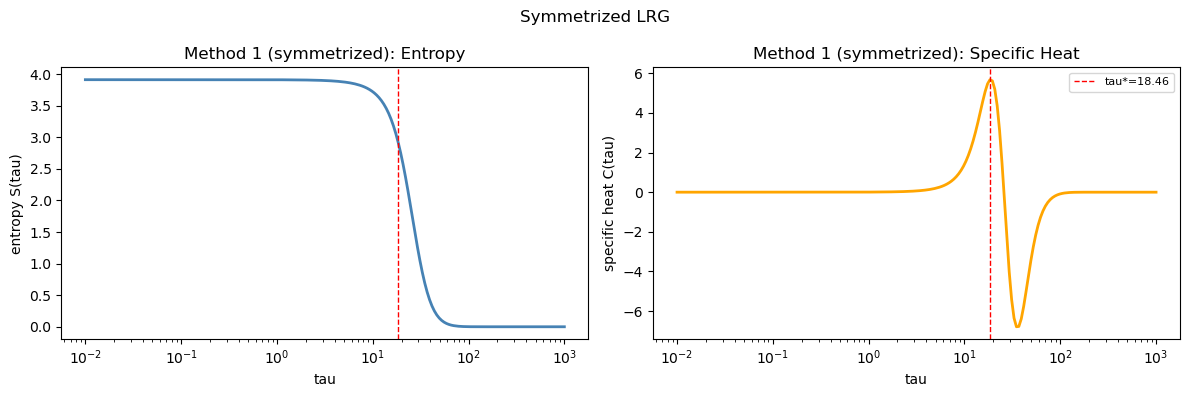

In [27]:
from scipy.linalg import expm
from scipy.signal import find_peaks
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

# symmetrize
A_sym = 0.5 * (A + A.T)
L_sym = np.diag(A_sym.sum(1)) - A_sym   # degree matrix minus adjacency

# eigendecompose (symmetric so real eigenvalues)
lam_sym, V_sym = np.linalg.eigh(L_sym)
lam_sym = np.clip(lam_sym, 0, None)

def density_matrix_sym(tau):
    K = V_sym @ np.diag(np.exp(-tau * lam_sym)) @ V_sym.T
    tr = np.trace(K)
    return K / tr if tr > 1e-12 else K

def entropy_sym(tau):
    rho = density_matrix_sym(tau)
    eigs = np.linalg.eigvalsh(rho)
    eigs = eigs[eigs > 1e-12]
    return -np.sum(eigs * np.log(eigs))

tau_grid = np.logspace(-2, 3, 200)
S_sym = np.array([entropy_sym(t) for t in tau_grid])
log_tau = np.log(tau_grid)
C_sym = -np.gradient(np.gradient(S_sym, log_tau), log_tau)

peaks_sym, _ = find_peaks(C_sym, height=0.01 * C_sym.max())
print("METHOD 1: Symmetrized LRG")
print(f"Natural scales (peaks in C):")
for p in peaks_sym:
    print(f"  tau* = {tau_grid[p]:.3f}   C = {C_sym[p]:.4f}")

# cluster at first peak
lbl_lrg_sym = None
n_lrg_sym = None
if len(peaks_sym) > 0:
    tau_star = tau_grid[peaks_sym[0]]
    rho = density_matrix_sym(tau_star)
    rho_diag = np.diag(rho)
    merge = np.zeros((n_demes, n_demes), dtype=bool)
    for i in range(n_demes):
        for j in range(i+1, n_demes):
            if rho[i,j] / max(min(rho_diag[i], rho_diag[j]), 1e-12) >= 1:
                merge[i,j] = True; merge[j,i] = True
    n_lrg_sym, lbl_lrg_sym = connected_components(csr_matrix(merge), directed=False)
    print(f"  -> {n_lrg_sym} natural clusters at tau*={tau_star:.3f}")
    print(f"  -> sizes: {[(lbl_lrg_sym==k).sum() for k in range(n_lrg_sym)]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tau_grid, S_sym, lw=2, color="steelblue")
axes[0].set_xscale("log"); axes[0].set_xlabel("tau"); axes[0].set_ylabel("entropy S(tau)")
axes[0].set_title("Method 1 (symmetrized): Entropy")
for p in peaks_sym: axes[0].axvline(tau_grid[p], color="r", ls="--", lw=1)

axes[1].plot(tau_grid, C_sym, lw=2, color="orange")
axes[1].set_xscale("log"); axes[1].set_xlabel("tau"); axes[1].set_ylabel("specific heat C(tau)")
axes[1].set_title("Method 1 (symmetrized): Specific Heat")
for p in peaks_sym:
    axes[1].axvline(tau_grid[p], color="r", ls="--", lw=1, label=f"tau*={tau_grid[p]:.2f}")
axes[1].legend(fontsize=8)
plt.suptitle("Symmetrized LRG")
plt.tight_layout(); plt.show()


METHOD 2: Directed LRG via Magnetic Laplacian

Encode directionality as a complex phase using the magnetic
Laplacian. The antisymmetric part of A becomes a phase factor
theta_ij. This preserves directionality while still giving a
Hermitian operator whose eigenvalues are real and non-negative.



METHOD 2: Magnetic Laplacian LRG
L_mag Hermitian? max|L - L^H| = 0.00e+00
Natural scales (peaks in C):
  tau* = 31.079   C = 220.9181
  -> 49 natural clusters at tau*=31.079
  -> sizes: [np.int64(1), np.int64(2), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]


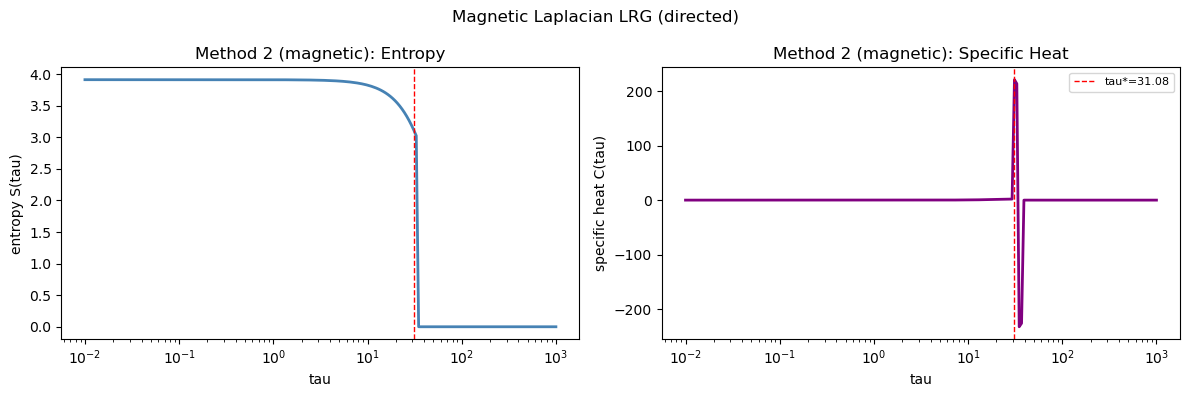

In [28]:
# decompose A into symmetric and antisymmetric parts
A_s = 0.5 * (A + A.T)      # symmetric part
A_a = 0.5 * (A - A.T)      # antisymmetric part (encodes direction)

# build magnetic Laplacian: L_mag[i,j] = -A_s[i,j] * exp(i * theta_ij)
# where theta_ij = pi/2 * sign(A_a[i,j]) encodes directionality as phase
theta = np.pi/2 * np.sign(A_a)
L_mag = np.diag(A_s.sum(1)).astype(complex)
for i in range(n_demes):
    for j in range(n_demes):
        if i != j:
            L_mag[i,j] = -A_s[i,j] * np.exp(1j * theta[i,j])

# L_mag should be Hermitian: L_mag = L_mag^H
print("METHOD 2: Magnetic Laplacian LRG")
print(f"L_mag Hermitian? max|L - L^H| = {np.abs(L_mag - L_mag.conj().T).max():.2e}")

# eigendecompose (Hermitian -> real eigenvalues)
lam_mag, V_mag = np.linalg.eigh(L_mag)
lam_mag = np.clip(lam_mag.real, 0, None)

def density_matrix_mag(tau):
    K = V_mag @ np.diag(np.exp(-tau * lam_mag)) @ V_mag.conj().T
    tr = np.trace(K).real
    return K.real / tr if tr > 1e-12 else K.real

def entropy_mag(tau):
    rho = density_matrix_mag(tau)
    eigs = np.linalg.eigvalsh(rho)
    eigs = eigs[eigs > 1e-12]
    return -np.sum(eigs * np.log(eigs))

S_mag = np.array([entropy_mag(t) for t in tau_grid])
C_mag = -np.gradient(np.gradient(S_mag, log_tau), log_tau)
peaks_mag, _ = find_peaks(C_mag, height=0.01 * C_mag.max())

print("Natural scales (peaks in C):")
for p in peaks_mag:
    print(f"  tau* = {tau_grid[p]:.3f}   C = {C_mag[p]:.4f}")

lbl_lrg_mag = None
n_lrg_mag = None
if len(peaks_mag) > 0:
    tau_star_mag = tau_grid[peaks_mag[0]]
    rho_mag = density_matrix_mag(tau_star_mag)
    rho_diag_mag = np.diag(rho_mag)
    merge_mag = np.zeros((n_demes, n_demes), dtype=bool)
    for i in range(n_demes):
        for j in range(i+1, n_demes):
            if rho_mag[i,j] / max(min(rho_diag_mag[i], rho_diag_mag[j]), 1e-12) >= 1:
                merge_mag[i,j] = True; merge_mag[j,i] = True
    n_lrg_mag, lbl_lrg_mag = connected_components(csr_matrix(merge_mag), directed=False)
    print(f"  -> {n_lrg_mag} natural clusters at tau*={tau_star_mag:.3f}")
    print(f"  -> sizes: {[(lbl_lrg_mag==k).sum() for k in range(n_lrg_mag)]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tau_grid, S_mag, lw=2, color="steelblue")
axes[0].set_xscale("log"); axes[0].set_xlabel("tau"); axes[0].set_ylabel("entropy S(tau)")
axes[0].set_title("Method 2 (magnetic): Entropy")
for p in peaks_mag: axes[0].axvline(tau_grid[p], color="r", ls="--", lw=1)

axes[1].plot(tau_grid, C_mag, lw=2, color="purple")
axes[1].set_xscale("log"); axes[1].set_xlabel("tau"); axes[1].set_ylabel("specific heat C(tau)")
axes[1].set_title("Method 2 (magnetic): Specific Heat")
for p in peaks_mag:
    axes[1].axvline(tau_grid[p], color="r", ls="--", lw=1, label=f"tau*={tau_grid[p]:.2f}")
axes[1].legend(fontsize=8)
plt.suptitle("Magnetic Laplacian LRG (directed)")
plt.tight_layout(); plt.show()


METHOD 3: GPCCA Crispness Score

Run GPCCA for a range of N_CLUSTERS values and pick the one
with the highest crispness score. Crispness measures how
well-separated the soft memberships are -- high crispness
means demes belong clearly to one super-deme, low crispness
means everything is fuzzy. This is the most natural way to
let the matrix A itself tell you the right number of clusters,
without approximating the directionality at all.



In [29]:
from pygpcca import GPCCA

cluster_range = range(2, 12)
crispness_scores = []
gpcca_results = {}

print("METHOD 3: GPCCA Crispness")
print(f"{'N_CLUSTERS':>12}  {'crispness':>12}")
print("-" * 28)
for m in cluster_range:
    try:
        g = GPCCA(A)
        g.optimize(m=m)
        cr = g.crispness
        crispness_scores.append(cr)
        gpcca_results[m] = g
        print(f"{m:>12}  {cr:>12.4f}")
    except Exception as e:
        crispness_scores.append(np.nan)
        print(f"{m:>12}  failed: {e}")

best_m = list(cluster_range)[np.nanargmax(crispness_scores)]
print(f"\nbest N_CLUSTERS by crispness: {best_m}  (crispness = {max(crispness_scores):.4f})")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(cluster_range), crispness_scores, "-o", lw=2, color="steelblue", ms=8)
ax.axvline(best_m, color="r", ls="--", lw=1.5, label=f"best m = {best_m}")
ax.set_xlabel("number of clusters")
ax.set_ylabel("GPCCA crispness")
ax.set_title("Method 3: GPCCA crispness vs number of clusters")
ax.legend()
plt.tight_layout(); plt.show()
python# ============================================================
# COMPARISON: all three methods side by side
# ============================================================

print("=" * 50)
print("SUMMARY: Natural number of clusters")
print("=" * 50)
print(f"  Method 1 (symmetrized LRG):  {n_lrg_sym}")
print(f"  Method 2 (magnetic LRG):     {n_lrg_mag}")
print(f"  Method 3 (GPCCA crispness):  {best_m}")
print(f"  Current choice:              {N_CLUSTERS}")
print()

# if methods agree, suggest rerunning with that number
suggestions = [x for x in [n_lrg_sym, n_lrg_mag, best_m] if x is not None]
if len(set(suggestions)) == 1:
    print(f"All methods agree: use N_CLUSTERS = {suggestions[0]}")
else:
    print(f"Methods disagree -- range suggested: {min(suggestions)} to {max(suggestions)}")
    print(f"Recommend running MFPT and Escape with each suggested value and comparing trajectory mismatch")


METHOD 3: GPCCA Crispness
  N_CLUSTERS     crispness
----------------------------
           2  failed: 'GPCCA' object has no attribute 'crispness'
           3  failed: 'GPCCA' object has no attribute 'crispness'
           4  failed: 'GPCCA' object has no attribute 'crispness'
           5  failed: Clustering into 5 clusters will split complex conjugate eigenvalues. Request one cluster more or less.
           6  failed: 'GPCCA' object has no attribute 'crispness'
           7  failed: 'GPCCA' object has no attribute 'crispness'
           8  failed: 'GPCCA' object has no attribute 'crispness'
           9  failed: Clustering into 9 clusters will split complex conjugate eigenvalues. Request one cluster more or less.
          10  failed: 'GPCCA' object has no attribute 'crispness'
          11  failed: 'GPCCA' object has no attribute 'crispness'


ValueError: All-NaN slice encountered

METHOD 1: Symmetrized LRG
peaks at tau = [np.float64(18.464)]

tau* = 18.464
rho diagonal range: 0.0095 to 0.0345
rho off-diagonal max: 0.0156
rho off-diagonal mean: 0.007277
  threshold=1.0: 50 clusters, sizes=[np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
  threshold=0.5: 1 clusters, sizes=[np.int64(50)]
  threshold=0.1: 1 clusters, sizes=[np.int64(50)]
  threshold=0.05: 1 clusters, sizes=[np.int64(50)]
  threshold=0.01: 1 clusters, sizes=[np.int64(50)]

METHOD 2 (revised): Random Walk Laplacian (directed)
peaks at tau = [np.float64(19.564)]
  threshold=1.0: 10 clusters, sizes=[np.int64(41), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
  threshold=0.5: 1 clusters, sizes=[np.int64(50)]
  threshold=0.1: 1 clusters, sizes=[np.int64(50)]
  threshold=0.05: 1 clusters, sizes=[np.int64(50)]
  threshold=0.01: 1 clusters, sizes=[np.int64(50)]

METHOD 3 (revised): GPCCA with metastability sc

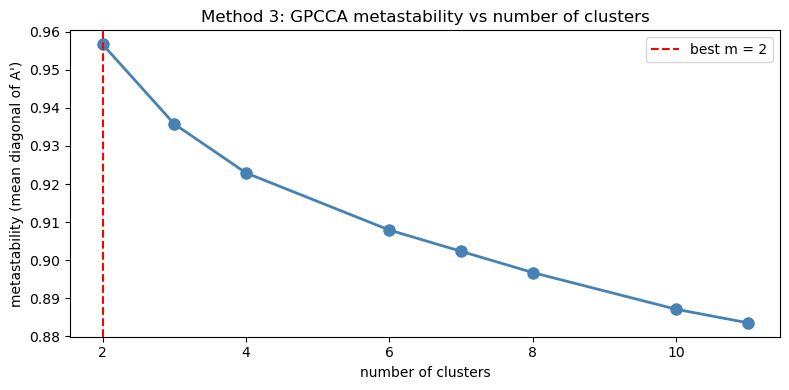

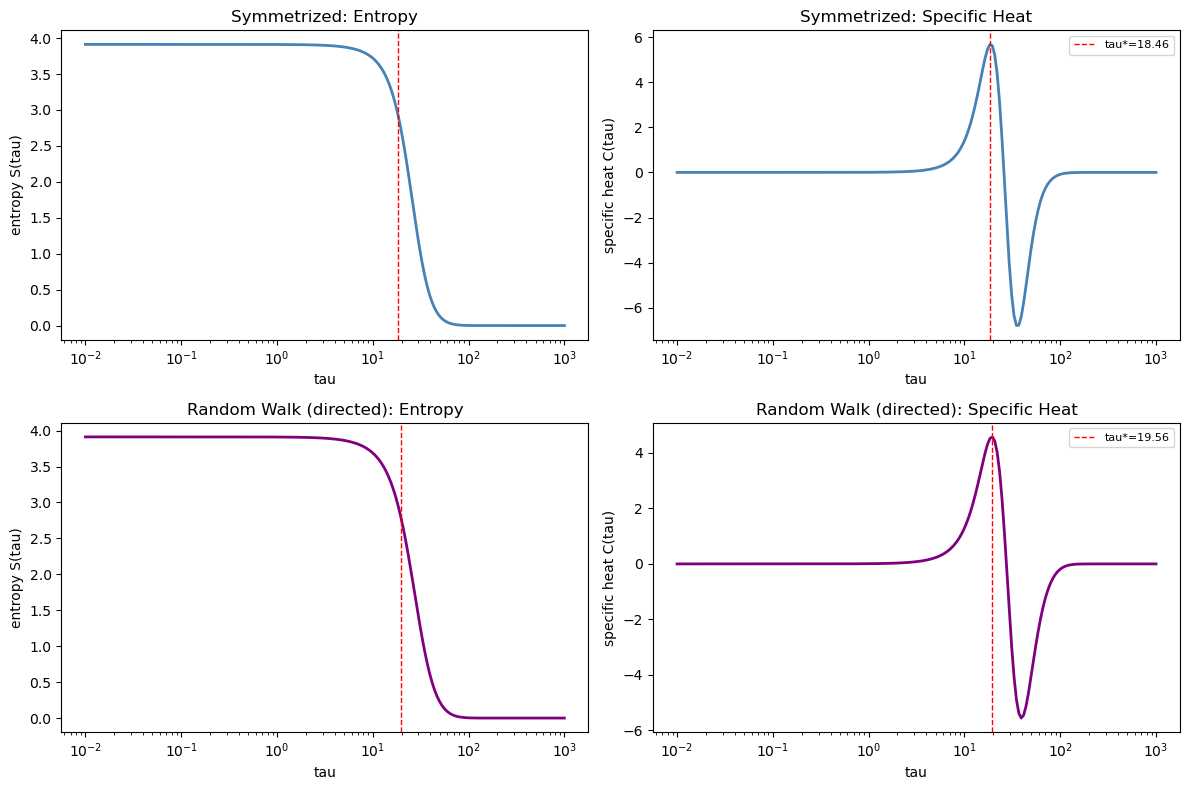

In [30]:
# ---- fix method 1: lower the merging threshold ----
# instead of >= 1, use a softer threshold
# and try multiple tau values not just the first peak

from scipy.linalg import expm
from scipy.signal import find_peaks
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

A_sym = 0.5 * (A + A.T)
L_sym = np.diag(A_sym.sum(1)) - A_sym
lam_sym, V_sym = np.linalg.eigh(L_sym)
lam_sym = np.clip(lam_sym, 0, None)

def density_matrix_sym(tau):
    K = V_sym @ np.diag(np.exp(-tau * lam_sym)) @ V_sym.T
    tr = np.trace(K)
    return K / tr if tr > 1e-12 else K

def entropy_sym(tau):
    rho = density_matrix_sym(tau)
    eigs = np.linalg.eigvalsh(rho)
    eigs = eigs[eigs > 1e-12]
    return -np.sum(eigs * np.log(eigs))

tau_grid = np.logspace(-2, 3, 200)
log_tau = np.log(tau_grid)
S_sym = np.array([entropy_sym(t) for t in tau_grid])
C_sym = -np.gradient(np.gradient(S_sym, log_tau), log_tau)
peaks_sym, _ = find_peaks(C_sym, height=0.01 * C_sym.max())

print("METHOD 1: Symmetrized LRG")
print(f"peaks at tau = {[round(tau_grid[p], 3) for p in peaks_sym]}")

# try a range of thresholds at the first peak tau
if len(peaks_sym) > 0:
    tau_star = tau_grid[peaks_sym[0]]
    rho = density_matrix_sym(tau_star)
    rho_diag = np.diag(rho)

    print(f"\ntau* = {tau_star:.3f}")
    print(f"rho diagonal range: {rho_diag.min():.4f} to {rho_diag.max():.4f}")
    print(f"rho off-diagonal max: {rho[~np.eye(n_demes,dtype=bool)].max():.4f}")
    print(f"rho off-diagonal mean: {rho[~np.eye(n_demes,dtype=bool)].mean():.6f}")

    # try different thresholds
    for threshold in [1.0, 0.5, 0.1, 0.05, 0.01]:
        merge = np.zeros((n_demes, n_demes), dtype=bool)
        for i in range(n_demes):
            for j in range(i+1, n_demes):
                if rho[i,j] / max(min(rho_diag[i], rho_diag[j]), 1e-12) >= threshold:
                    merge[i,j] = True; merge[j,i] = True
        n_cl, lbl_cl = connected_components(csr_matrix(merge), directed=False)
        print(f"  threshold={threshold}: {n_cl} clusters, sizes={sorted([(lbl_cl==k).sum() for k in range(n_cl)], reverse=True)[:8]}")

# ---- fix method 2: skip magnetic, use directed random walk Laplacian instead ----
# L_rw = I - D^{-1} A  where D = diag(row sums)
# This is the natural Laplacian for a directed network
print("\nMETHOD 2 (revised): Random Walk Laplacian (directed)")
D_inv = np.diag(1.0 / A.sum(1))
L_rw = np.eye(n_demes) - D_inv @ A   # = I - A since A is already row-stochastic

# symmetrize via pi-weighting for eigendecomposition
pi_A = stationary(A)
Pi_half = np.diag(np.sqrt(pi_A))
Pi_half_inv = np.diag(1.0 / np.sqrt(pi_A))
L_sym_rw = Pi_half @ L_rw @ Pi_half_inv   # symmetrized version

lam_rw, V_rw = np.linalg.eigh(0.5*(L_sym_rw + L_sym_rw.T))
lam_rw = np.clip(lam_rw, 0, None)

def density_matrix_rw(tau):
    K = V_rw @ np.diag(np.exp(-tau * lam_rw)) @ V_rw.T
    tr = np.trace(K)
    return K / tr if tr > 1e-12 else K

def entropy_rw(tau):
    rho = density_matrix_rw(tau)
    eigs = np.linalg.eigvalsh(rho)
    eigs = eigs[eigs > 1e-12]
    return -np.sum(eigs * np.log(eigs))

S_rw = np.array([entropy_rw(t) for t in tau_grid])
C_rw = -np.gradient(np.gradient(S_rw, log_tau), log_tau)
peaks_rw, _ = find_peaks(C_rw, height=0.01 * C_rw.max())

print(f"peaks at tau = {[round(tau_grid[p], 3) for p in peaks_rw]}")
if len(peaks_rw) > 0:
    tau_star_rw = tau_grid[peaks_rw[0]]
    rho_rw = density_matrix_rw(tau_star_rw)
    rho_diag_rw = np.diag(rho_rw)
    for threshold in [1.0, 0.5, 0.1, 0.05, 0.01]:
        merge = np.zeros((n_demes, n_demes), dtype=bool)
        for i in range(n_demes):
            for j in range(i+1, n_demes):
                if rho_rw[i,j] / max(min(rho_diag_rw[i], rho_diag_rw[j]), 1e-12) >= threshold:
                    merge[i,j] = True; merge[j,i] = True
        n_cl, lbl_cl = connected_components(csr_matrix(merge), directed=False)
        print(f"  threshold={threshold}: {n_cl} clusters, sizes={sorted([(lbl_cl==k).sum() for k in range(n_cl)], reverse=True)[:8]}")

# ---- fix method 3: use gpcca coarse_grained_stationary_probability instead of crispness ----
print("\nMETHOD 3 (revised): GPCCA with metastability score")
cluster_range = range(2, 12)
meta_scores = []

print(f"{'N_CLUSTERS':>12}  {'metastability':>14}")
print("-" * 30)
for m in cluster_range:
    try:
        g = GPCCA(A)
        g.optimize(m=m)
        # use trace of coarse transition matrix as metastability proxy
        # (higher diagonal = more metastable clusters)
        meta = np.trace(g.coarse_grained_transition_matrix) / m
        meta_scores.append(meta)
        print(f"{m:>12}  {meta:>14.4f}")
    except Exception as e:
        meta_scores.append(np.nan)
        print(f"{m:>12}  failed: {str(e)[:60]}")

valid = [(m, s) for m, s in zip(cluster_range, meta_scores) if not np.isnan(s)]
if valid:
    best_m = max(valid, key=lambda x: x[1])[0]
    print(f"\nbest N_CLUSTERS by metastability: {best_m}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot([m for m,s in valid], [s for m,s in valid], "-o", lw=2, color="steelblue", ms=8)
    ax.axvline(best_m, color="r", ls="--", lw=1.5, label=f"best m = {best_m}")
    ax.set_xlabel("number of clusters")
    ax.set_ylabel("metastability (mean diagonal of A')")
    ax.set_title("Method 3: GPCCA metastability vs number of clusters")
    ax.legend()
    plt.tight_layout()
    plt.show()

# ---- plot entropy and specific heat for both LRG methods ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for row, (S_vals, C_vals, peaks, name, color) in enumerate([
    (S_sym, C_sym, peaks_sym, "Symmetrized", "steelblue"),
    (S_rw,  C_rw,  peaks_rw,  "Random Walk (directed)", "purple")
]):
    axes[row,0].plot(tau_grid, S_vals, lw=2, color=color)
    axes[row,0].set_xscale("log"); axes[row,0].set_xlabel("tau")
    axes[row,0].set_ylabel("entropy S(tau)")
    axes[row,0].set_title(f"{name}: Entropy")
    for p in peaks: axes[row,0].axvline(tau_grid[p], color="r", ls="--", lw=1)

    axes[row,1].plot(tau_grid, C_vals, lw=2, color=color)
    axes[row,1].set_xscale("log"); axes[row,1].set_xlabel("tau")
    axes[row,1].set_ylabel("specific heat C(tau)")
    axes[row,1].set_title(f"{name}: Specific Heat")
    for p in peaks:
        axes[row,1].axvline(tau_grid[p], color="r", ls="--", lw=1,
                            label=f"tau*={tau_grid[p]:.2f}")
    axes[row,1].legend(fontsize=8)

plt.tight_layout()
plt.show()